Load data

In [27]:
import pandas as pd
import numpy as np

BASE = "C:/Users/nikes/OneDrive/Desktop/Beginner-to-Architect/aiguard/airguard-uk/airguard-uk"

train = pd.read_csv(f"{BASE}/models/train_forecast.csv")
test  = pd.read_csv(f"{BASE}/models/test_forecast.csv")

FEATURES = pd.read_csv(f"{BASE}/models/feature_list.csv")['0'].tolist()
TARGET = 'DAQI_6h'

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

# Fill any remaining NaN
X_train = X_train.fillna(X_train.median())
X_test  = X_test.fillna(X_train.median())

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Features: {len(FEATURES)}")
print(f"\ny_train distribution:\n{y_train.value_counts().sort_index()}")

X_train: (175195, 105)
X_test:  (43775, 105)
Features: 105

y_train distribution:
DAQI_6h
0    171783
1      3007
2       405
Name: count, dtype: int64


SMOTE

In [28]:
from imblearn.over_sampling import SMOTE

print("Applying SMOTE...")
print(f"Before: {dict(y_train.value_counts().sort_index())}")

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"After:  {dict(pd.Series(y_train_bal).value_counts().sort_index())}")
print(f"Training set size after SMOTE: {len(X_train_bal):,}")

Applying SMOTE...
Before: {0: np.int64(171783), 1: np.int64(3007), 2: np.int64(405)}
After:  {0: np.int64(171783), 1: np.int64(171783), 2: np.int64(171783)}
Training set size after SMOTE: 515,349


Train XGBoost

In [29]:
from xgboost import XGBClassifier

print("Training XGBoost 6h forecast model...")

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("Training complete.")

Training XGBoost 6h forecast model...
[0]	validation_0-mlogloss:1.06619
[50]	validation_0-mlogloss:0.55117
[100]	validation_0-mlogloss:0.46665
[150]	validation_0-mlogloss:0.41632
[200]	validation_0-mlogloss:0.37766
[250]	validation_0-mlogloss:0.34176
[299]	validation_0-mlogloss:0.31040
Training complete.


Evaluate

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         Low      0.992     0.895     0.941     42500
    Moderate      0.154     0.672     0.250      1150
   Dangerous      0.076     0.232     0.115       125

    accuracy                          0.888     43775
   macro avg      0.407     0.600     0.435     43775
weighted avg      0.967     0.888     0.921     43775



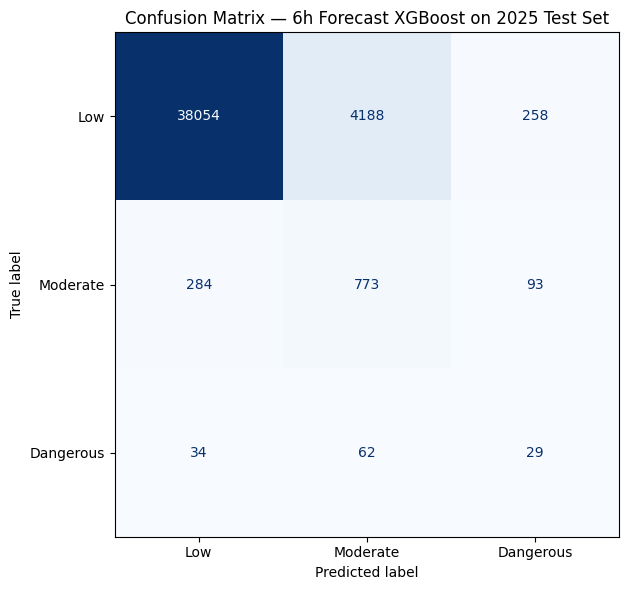

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_test, y_pred,
    target_names=['Low', 'Moderate', 'Dangerous'],
    digits=3
))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low', 'Moderate', 'Dangerous']
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — 6h Forecast XGBoost on 2025 Test Set')
plt.tight_layout()
plt.savefig(f"{BASE}/plots/confusion_matrix_forecast.png")
plt.show()

Feature importance

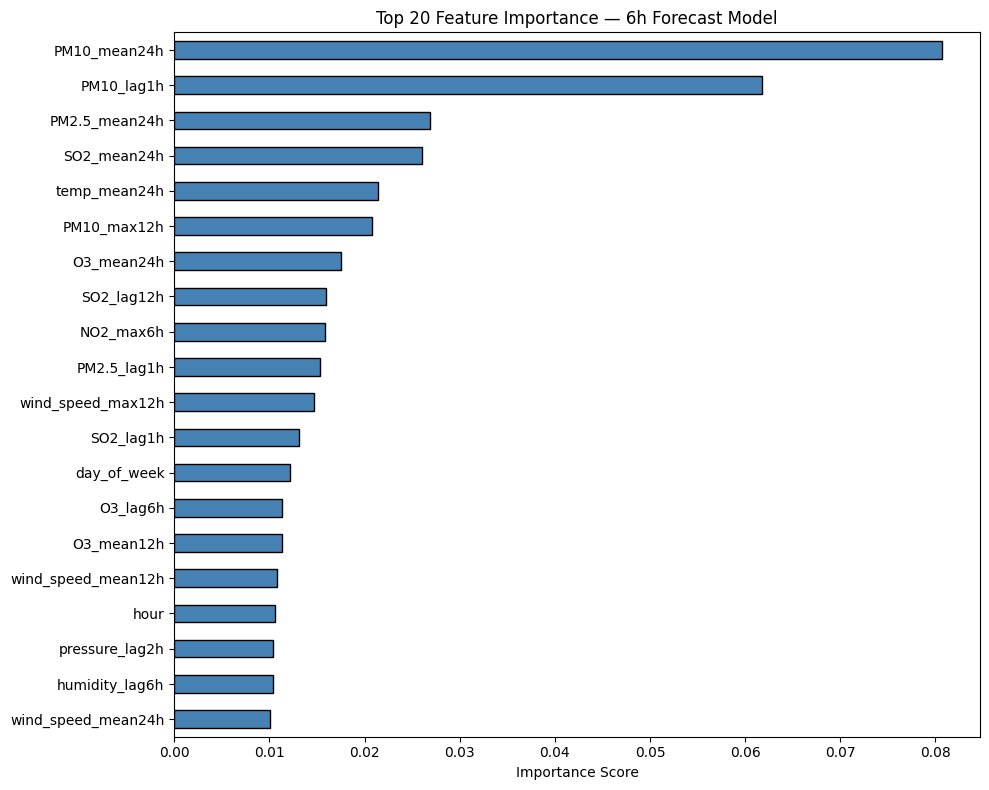


Top 10 features:
PM10_mean24h     0.080645
PM10_lag1h       0.061783
PM2.5_mean24h    0.026872
SO2_mean24h      0.026077
temp_mean24h     0.021411
PM10_max12h      0.020763
O3_mean24h       0.017578
SO2_lag12h       0.015908
NO2_max6h        0.015812
PM2.5_lag1h      0.015304


In [33]:
importances = pd.Series(model.feature_importances_, index=FEATURES)
top20 = importances.sort_values(ascending=False).head(20)

top20.sort_values().plot(kind='barh', figsize=(10,8), color='steelblue', edgecolor='black')
plt.title('Top 20 Feature Importance — 6h Forecast Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(f"{BASE}/plots/feature_importance_forecast.png")
plt.show()

print("\nTop 10 features:")
print(top20.head(10).to_string())

Save model

In [32]:
import joblib
import os

joblib.dump(model, f"{BASE}/models/xgboost_forecast_model.pkl")

# Save feature list and train median for app use
X_train.median().to_csv(f"{BASE}/models/train_median.csv")

print(f"Saved → models/xgboost_forecast_model.pkl")
print(f"Saved → models/train_median.csv")

Saved → models/xgboost_forecast_model.pkl
Saved → models/train_median.csv


Here's why 6 hours is actually the better product:

- A 6-hour warning is still genuinely useful enough time for schools to cancel outdoor sports, hospitals to prepare, vulnerable people to plan
- The UK Met Office's own air quality forecasts are most reliable at 6-12 hours
- The lag features (1h, 2h, 3h, 6h ago) give very strong signal for what will happen in 6 hours